# Clasificación Automática de Modulaciones (AMC)
## Entrenamiento — CNN

Este notebook entrena y evalúa **un solo modelo** (CNN) sobre el dataset RadioML 2016.10a.
Las clases de arquitectura, la carga de datos y el loop de entrenamiento viven en `../common/`
(compartido por los notebooks `cnn/`, `lstm/`, `gru/`, `tcn/`) para no reentrenar ni duplicar código
entre notebooks. La comparación entre arquitecturas se hace aparte, en `../comparacion/comparacion.ipynb`,
que solo carga los pesos ya entrenados aquí.

Para probar otra profundidad/ancho, modificar `MODEL_KWARGS` más abajo y volver a correr el notebook
— la config usada queda guardada en `history.pkl` junto con el historial de entrenamiento, así
`comparacion.ipynb` puede reconstruir el modelo exacto antes de cargar los pesos.


## 1. Imports y configuración

In [ ]:
import sys
sys.path.insert(0, "..")

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common.models import CNNBaseline
from common.data import load_radioml_digital, split_dataset, make_loader, augment_rotate_iq
from common.train import train_model, SNRCurriculum, evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 10
SEED = 42

# Hiperparámetros de arquitectura — modificar acá para probar otra profundidad/ancho.
# No incluye n_classes (se completa con el dataset) para poder reusar la misma config
# sin importar cuántas clases tenga el split.
MODEL_KWARGS = dict(channels=(64, 64), kernel_size=3, fc_hidden=128, dropout=0.5)

# Entrenamiento por grupos de SNR (ver common/train.py::SNRCurriculum): se entrena primero con el
# grupo de SNR más alto y se van SUMANDO grupos más bajos (`group_size` niveles de SNR cada uno).
# Cada grupo se entrena hasta que la val accuracy (sobre todos los SNR) deja de mejorar durante
# `patience` épocas; si sumar un grupo no mejora la accuracy, se corta y se queda con los mejores
# pesos. En este modo `PATIENCE` no se usa y EPOCHS es solo un tope global de seguridad.
# Poner USE_CURRICULUM = False para entrenar con todos los SNR mezclados desde el inicio.
USE_CURRICULUM = False
CURRICULUM_KWARGS = dict(group_size=4, patience=3, min_gain=0.005, max_epochs_per_stage=15)
if USE_CURRICULUM:
    EPOCHS = 80

print(f"Usando dispositivo: {DEVICE}")

## 2. Carga y preparación del dataset

In [2]:
X, y, snrs, le = load_radioml_digital(seed=SEED)
N_CLASSES = len(le.classes_)
print(f"Clases ({N_CLASSES}): {list(le.classes_)}")

(X_train, y_train, snr_train), (X_val, y_val, snr_val), (X_test, y_test, snr_test) = split_dataset(
    X, y, snrs, seed=SEED
)

# Data augmentation por rotación de constelación I/Q, solo en train (mismo criterio que
# cnn_preproc/) — así la comparación entre arquitecturas no mezcla el efecto de la
# augmentation con el de la arquitectura en sí.
X_train, y_train, snr_train = augment_rotate_iq(X_train, y_train, snr_train)
print(f"Train (aumentado): {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

Clases (8): ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK']
Train (aumentado): (384000, 2, 128) | Val: (32000, 2, 128) | Test: (32000, 2, 128)


## 3. Entrenamiento — CNN

In [3]:
print("=== CNN ===")
print(f"Configuración: {MODEL_KWARGS}")
model = CNNBaseline(n_classes=N_CLASSES, **MODEL_KWARGS)
print(f"Parámetros: {model.count_parameters():,}")

curriculum = (SNRCurriculum(X_train, y_train, snr_train, batch_size=BATCH_SIZE, **CURRICULUM_KWARGS)
              if USE_CURRICULUM else None)

model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, device=DEVICE, curriculum=curriculum
)
history["model_kwargs"] = MODEL_KWARGS
history["curriculum"] = CURRICULUM_KWARGS if USE_CURRICULUM else None

torch.save(model.state_dict(), "cnn.pt")
with open("history.pkl", "wb") as f:
    pickle.dump(history, f)

=== CNN ===
Configuración: {'channels': (64, 64), 'kernel_size': 3, 'fc_hidden': 128, 'dropout': 0.5}
Parámetros: 1,063,048
[curriculum] etapa 1/5: SNR >= 12 dB (76640 muestras)
Época   1 | SNR >=  12 dB | Train Loss: 0.7481 | Val Loss: 11.1502 | Val Acc: 0.1194 (mejor 0.1194)
Época   2 | SNR >=  12 dB | Train Loss: 0.3763 | Val Loss: 11.3637 | Val Acc: 0.1627 (mejor 0.1627)
Época   3 | SNR >=  12 dB | Train Loss: 0.3144 | Val Loss: 4.9617 | Val Acc: 0.1723 (mejor 0.1723)
Época   4 | SNR >=  12 dB | Train Loss: 0.2698 | Val Loss: 14.7861 | Val Acc: 0.1688 (mejor 0.1723)
Época   5 | SNR >=  12 dB | Train Loss: 0.2372 | Val Loss: 10.2846 | Val Acc: 0.1731 (mejor 0.1723)
Época   6 | SNR >=  12 dB | Train Loss: 0.2137 | Val Loss: 16.6956 | Val Acc: 0.1268 (mejor 0.1723)
Época   7 | SNR >=  12 dB | Train Loss: 0.1942 | Val Loss: 20.1694 | Val Acc: 0.1257 (mejor 0.1723)
Época   8 | SNR >=  12 dB | Train Loss: 0.1714 | Val Loss: 44.1779 | Val Acc: 0.1248 (mejor 0.1723)
Época   9 | SNR >=  12 

## 4. Evaluación

In [4]:
acc = overall_accuracy(model, X_test, y_test, device=DEVICE)
snr_acc = evaluate_by_snr(model, X_test, y_test, snr_test, device=DEVICE)

print(f"Accuracy global — CNN: {acc:.4f}")
print(f"Parámetros: {model.count_parameters():,}")

Accuracy global — CNN: 0.2526
Parámetros: 1,063,048


## 5. Gráficos

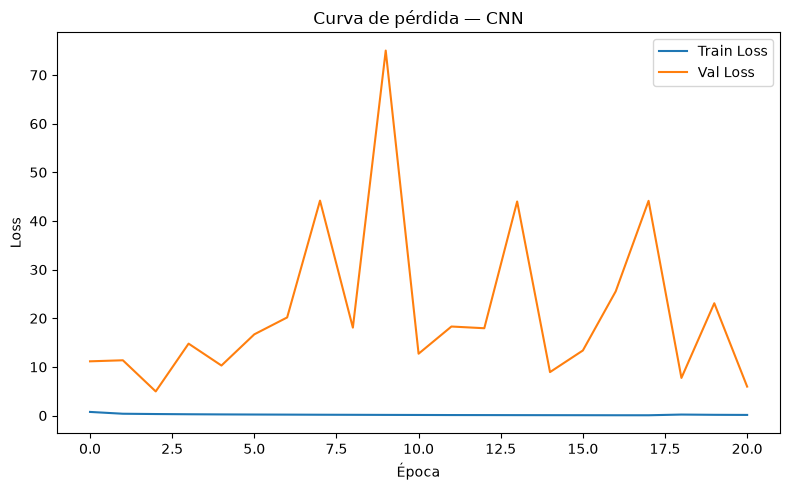

In [5]:
# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida — CNN")
plt.legend()
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150)
plt.show()

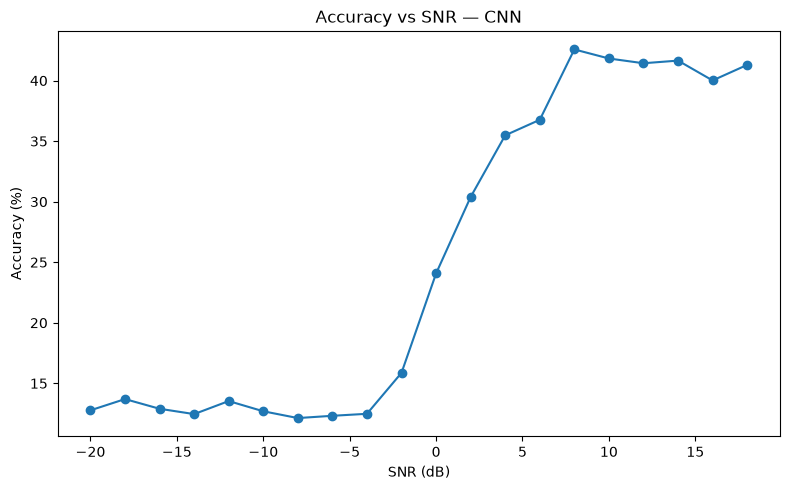

In [6]:
# Accuracy vs SNR
snr_levels = sorted(snr_acc.keys())
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — CNN")
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

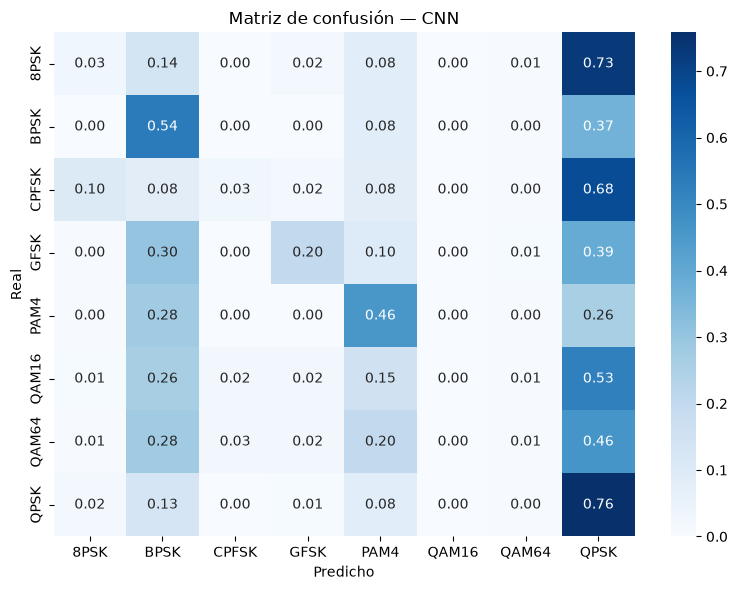

In [7]:
# Matriz de confusión (todos los SNR)
cm = compute_cm(model, X_test, y_test, device=DEVICE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CNN")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

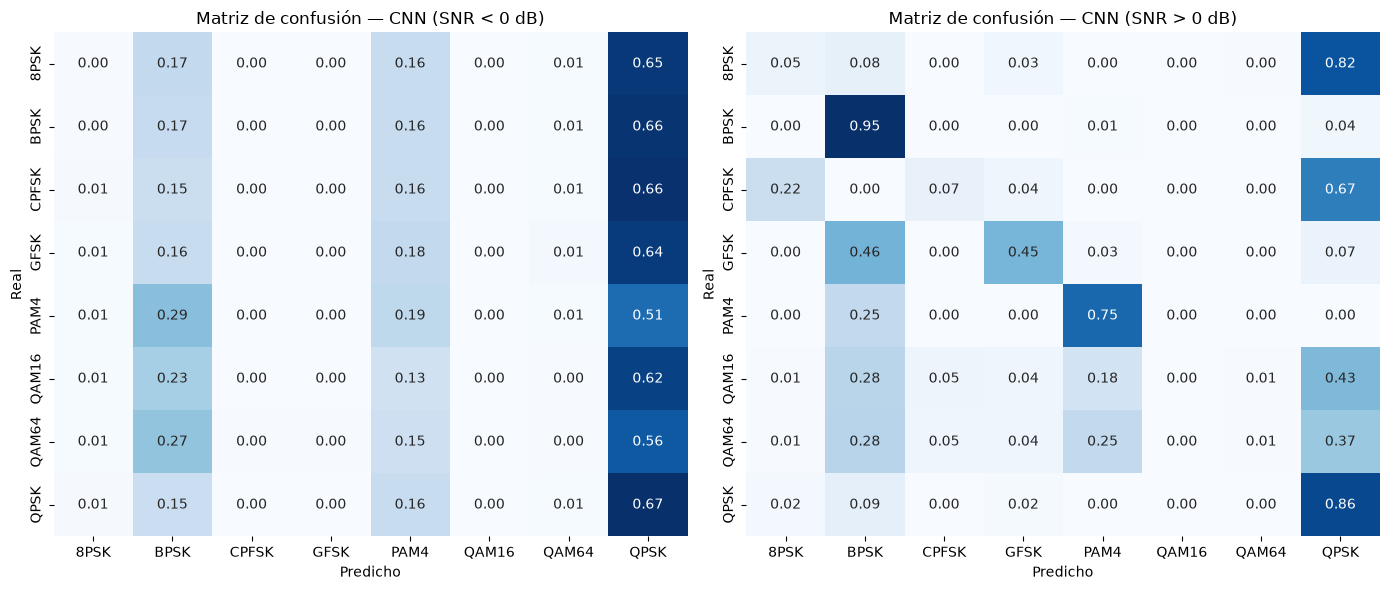

In [8]:
# Matrices de confusión por rango de SNR (bajo: <0 dB, alto: >0 dB)
mask_low = snr_test < 0
mask_high = snr_test > 0

cm_low = compute_cm(model, X_test[mask_low], y_test[mask_low], device=DEVICE)
cm_high = compute_cm(model, X_test[mask_high], y_test[mask_high], device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm_snr, titulo in zip(axes, [cm_low, cm_high], ["SNR < 0 dB", "SNR > 0 dB"]):
    sns.heatmap(cm_snr, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — CNN ({titulo})")
plt.tight_layout()
plt.savefig("confusion_matrix_por_snr.png", dpi=150)
plt.show()

In [9]:
# --- Guardar esta corrida (no pisa nada: cada ejecución crea su propia carpeta) ---------------------
import json
from datetime import datetime
from pathlib import Path

LR = 1e-3        # lr usado en train_model(...) de este notebook (default 1e-3)
AUGMENT = True   # augment_rotate_iq aplicado en train
SCHEDULER = False  # no se usó use_lr_scheduler
DATA_CONFIG = {"data_source": "radioml"}

_folder = globals().get("RUN_NAME", Path.cwd().name)
_ARCH = {"cnn": ("cnn", "iq"), "lstm": ("lstm", "iq"), "gru": ("gru", "iq"), "tcn": ("tcn", "iq"),
         "cnn_ap": ("cnn", "ap"), "tcn_ap": ("tcn", "ap"), "cnn_preproc": ("ulcnn", "iq")}
_arch, _repr = _ARCH.get(_folder, (_folder, "iq"))
_cur = bool(globals().get("USE_CURRICULUM", False))
_low, _pos = snr_test <= -10, snr_test > 0

_cfg = {
    "arch": _arch, "repr": _repr, "target": "notebook", "params": int(model.count_parameters()),
    "model_kwargs": {k: (list(v) if isinstance(v, tuple) else v) for k, v in MODEL_KWARGS.items()},
    "lr": LR, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "patience": PATIENCE,
    "augment": AUGMENT, "curriculum": _cur, "lr_scheduler": SCHEDULER,
    "curriculum_kwargs": globals().get("CURRICULUM_KWARGS") if _cur else None,
    **DATA_CONFIG, "seed": SEED, "fuente": f"notebook {_folder}", "fecha": datetime.now().isoformat(timespec="seconds"),
}
_metrics = {
    "accuracy_global": float(acc),
    "accuracy_snr_menor_igual_-10": float(overall_accuracy(model, X_test[_low], y_test[_low], device=DEVICE)),
    "accuracy_snr_mayor_0": float(overall_accuracy(model, X_test[_pos], y_test[_pos], device=DEVICE)),
    "accuracy_por_snr": {str(int(k)): float(v) for k, v in snr_acc.items()},
    "parametros": _cfg["params"],
    "epocas_entrenadas": len(history["train_loss"]),
    "mejor_val_acc": float(max(history["val_acc"])),
    "mejor_val_loss": float(min(history["val_loss"])),
    "segundos_entrenamiento": 0.0,  # el notebook no mide el tiempo
}

_rid = (f"{_arch}_{_repr}_p{_cfg['params']}_lr{LR:g}_bs{BATCH_SIZE}_aug{int(AUGMENT)}_cur{int(_cur)}{'_sch' if SCHEDULER else ''}"
        f"_seed{SEED}_nb{datetime.now():%Y%m%d-%H%M%S}")
_out = Path(globals().get("SWEEP_DIR", Path.cwd().resolve().parents[1] / "Resultados" / "sweep")) / _rid
_out.mkdir(parents=True, exist_ok=False)  # falla en vez de pisar si ya existiera
(_out / "config.json").write_text(json.dumps(_cfg, indent=2, ensure_ascii=False), encoding="utf-8")
(_out / "history.json").write_text(json.dumps(
    {k: [float(x) for x in v] for k, v in history.items() if isinstance(v, list)}), encoding="utf-8")
torch.save(model.state_dict(), _out / "model.pt")
(_out / "metrics.json").write_text(json.dumps(_metrics, indent=2), encoding="utf-8")  # marca de "terminada"
print(f"Corrida guardada en {_out}")

Corrida guardada en D:\CEIA\Proyecto_AMC\Resultados\sweep\cnn_iq_p1063048_lr0.001_bs256_aug1_cur1_seed42_nb20261003-112358
